# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Andika Ardiansyah
- **Email:** cdcc676d6y2392@student.devacademy.id
- **ID Dicoding:** CDCC676D6Y2392

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** ***"Pada musim (season) manakah rata-rata jumlah penyewaan sepeda tertinggi, dan bagaimana proporsi antara pengguna casual dan registered pada musim tersebut?"***


- **Pertanyaan 2:** ***"Bagaimana pola penyewaan sepeda per jam pada hari kerja (workingday) dibandingkan dengan hari libur (holiday), dan jam berapa yang menjadi titik puncak penyewaan pada kedua kategori tersebut?"***

## Import Semua Packages/Library yang Digunakan

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [6]:
day_df = pd.read_csv('https://raw.githubusercontent.com/Ardiansyah251104/Analisis-Data/main/data/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [7]:
hour_df = pd.read_csv('https://raw.githubusercontent.com/Ardiansyah251104/Analisis-Data/main/data/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- xxx
- xxx

### Assessing Data

#### Menilai Tabel `day_df`

In [8]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [9]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [10]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [11]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [12]:
day_df.nunique()

,0
instant,731
dteday,731
season,4
yr,2
mnth,12
holiday,2
weekday,7
workingday,2
weathersit,3
temp,499


**Steps to Take:**
- Mengecek apakah ada type data yang tidak sesuai
- Memastikan tidak ada data yang kosong pada seiap kolom
- Memastikan tidak ada yang duplicate atau double
- Mendeteksi outliers atau nilai yang tidak logis.
- Mengecek apakah nilai unik dalam kolom kategori sudah benar.

**Insight:** (Opsional)
- Ditemukan type data yang tidak sesuai untuk tanggal oleh sebab itu saya mengubahnya di tahapan selanjutnya

#### Menilai Tabel `hour_df`

In [13]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [14]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [15]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [16]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [17]:
hour_df.nunique()

,0
instant,17379
dteday,731
season,4
yr,2
mnth,12
hr,24
holiday,2
weekday,7
workingday,2
weathersit,4


**Steps to Take:**
- Mengecek apakah ada type data yang tidak sesuai
- Memastikan tidak ada data yang kosong pada seiap kolom
- Memastikan tidak ada yang duplicate atau double
- Mendeteksi outliers atau nilai yang tidak logis.
- Mengecek apakah nilai unik dalam kolom kategori sudah benar.

**Insight:** (Opsional)
- Ditemukan type data yang tidak sesuai untuk tanggal oleh sebab itu saya mengubahnya di tahapan selanjutnya.

### Cleaning Data

#### Memperbaiki Type Data `day_df`


In [18]:
datetime_columns = ["dteday"]

for column in datetime_columns:
  day_df[column] = pd.to_datetime(day_df[column])

In [19]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

#### Mengubah Angka Menjadi Label

In [20]:
# Di Markdown: ## Membersihkan data dengan mengubah angka menjadi label kategori

# Mengubah angka menjadi label untuk Season
day_df['season'] = day_df['season'].replace({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

# Mengubah angka menjadi label untuk Weather
day_df['weathersit'] = day_df['weathersit'].replace({
    1: 'Clear',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Thunderstorm'
})

# Menampilkan hasil untuk memastikan tidak NaN
print(day_df[['season', 'weathersit']].head())
day_df.head()

   season    weathersit
0  Spring  Misty/Cloudy
1  Spring  Misty/Cloudy
2  Spring         Clear
3  Spring         Clear
4  Spring         Clear


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,6,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,0,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [21]:
print(day_df.isna().sum())
print(day_df.duplicated().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
0


In [22]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,6,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,0,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- xxx
- xxx

#### Memperbaiki Type Data `hour_df`

In [23]:
datetime_columns = ["dteday"]

for column in datetime_columns:
  hour_df[column] = pd.to_datetime(hour_df[column])

hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

#### Mengubah Angka Menjadi Label (Labelling)

In [24]:
# Di Markdown: ## Membersihkan data dengan mengubah angka menjadi label kategori

# Mengubah angka menjadi label untuk Season
hour_df['season'] = day_df['season'].replace({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

# Mengubah angka menjadi label untuk Weather
hour_df['weathersit'] = day_df['weathersit'].replace({
    1: 'Clear',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Thunderstorm'
})

# Menampilkan hasil untuk memastikan tidak NaN
print(hour_df[['season', 'weathersit']].head())
hour_df.head()

   season    weathersit
0  Spring  Misty/Cloudy
1  Spring  Misty/Cloudy
2  Spring         Clear
3  Spring         Clear
4  Spring         Clear


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,0,6,0,Misty/Cloudy,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,0,1,1,0,6,0,Misty/Cloudy,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,0,1,2,0,6,0,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,0,1,3,0,6,0,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,0,1,4,0,6,0,Clear,0.24,0.2879,0.75,0.0,0,1,1


## Exploratory Data Analysis (EDA)

### Explore `day_df`

In [25]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731,731.000000,731.000000,731.000000,731.000000,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,NaN,NaN,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,NaN,NaN,NaN,NaN,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,0.500684,6.519836,0.028728,2.997264,0.683995,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,0.000000,4.000000,0.000000,1.000000,0.000000,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,1.000000,7.000000,0.000000,3.000000,1.000000,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,1.000000,10.000000,0.000000,5.000000,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,1.000000,12.000000,1.000000,6.000000,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


#### Explore Berdasarkan Musim (Season)

In [26]:
day_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "std"]
}).sort_values(by=("cnt", "mean"), ascending=False)

cnt                                
         max   min         mean          std
season                                      
Fall    8714  1115  5644.303191  1459.800381
Summer  8362   795  4992.331522  1695.977235
Winter  8555    22  4728.162921  1699.615261
Spring  7836   431  2604.132597  1399.942119

#### Explore Berdasarkan Kondisi Cuaca (Weathersit)

In [27]:
day_df.groupby(by="weathersit").agg({
    "cnt": ["max", "min", "mean", "std"]
}).sort_values(by=("cnt", "mean"), ascending=False)

cnt                               
                  max  min         mean          std
weathersit                                          
Clear            8714  431  4876.786177  1879.483989
Misty/Cloudy     8362  605  4035.862348  1809.109918
Light Snow/Rain  4639   22  1803.285714  1240.284449

#### Explore Berdasarkan Hari Kerja (1) vs Hari Libur (0)

In [28]:
day_df.groupby(by="workingday").agg({
    "cnt": ["max", "min", "mean", "std"]
})

cnt                               
             max  min         mean          std
workingday                                     
0           8714  605  4330.168831  2052.141245
1           8362   22  4584.820000  1878.415583

#### Analisis Korelasi

In [29]:
day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()

,temp,atemp,hum,windspeed,cnt
temp,1.000000,0.991702,0.126963,-0.157944,0.627494
atemp,0.991702,1.000000,0.139988,-0.183643,0.631066
hum,0.126963,0.139988,1.000000,-0.248489,-0.100659
windspeed,-0.157944,-0.183643,-0.248489,1.000000,-0.234545
cnt,0.627494,0.631066,-0.100659,-0.234545,1.000000


**Insight:** (Opsional)
- Musim Fall memiliki rata-rata penyewaan tertinggi dibandingkan musim lainnya.
- Kondisi cuaca Clear/Partly Cloudy sangat mendukung peningkatan jumlah penyewa secara signifikan.
- Terdapat korelasi positif yang cukup kuat antara suhu (temp) dengan jumlah penyewa (cnt), yang berarti semakin hangat cuaca, semakin banyak orang yang menyewa sepeda.

### Explore `hour_df`

In [30]:
hour_df.describe()

,instant,dteday,yr,mnth,hr,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


#### Explore Berdasarkan hour

In [31]:
hour_df.groupby(by="hr").agg({
    "cnt": ["max", "min", "mean", "std"]
}).sort_values(by=("cnt", "mean"), ascending=False)

cnt                            
    max min        mean         std
hr                                 
17  976  15  461.452055  232.656611
18  977  23  425.510989  224.639304
8   839   5  359.011004  235.189285
16  783  11  311.983562  148.682618
19  743  11  311.523352  161.050359
13  760  11  253.661180  148.107657
12  776   3  253.315934  145.081134
15  750   7  251.233196  144.632541
14  750  12  240.949246  147.271574
20  567  11  226.030220  119.670164
9   426  14  219.309491   93.703458
7   596   1  212.064649  161.441936
11  663  10  208.143054  127.495536
10  539   8  173.668501  102.205413
21  584   6  172.314560   89.788893
22  502   9  131.335165   69.937782
23  256   2   87.831044   50.846889
6   213   1   76.044138   55.084348
0   283   2   53.898072   42.307910
1   168   1   33.375691   33.538727
2   132   1   22.869930   26.578642
5    66   1   19.889819   13.200765
3    79   1   11.727403   13.239190
4    28   1    6.352941    4.143818

#### Explore Berdasarkan Hari kerja Vs Hari Libur

In [32]:
hour_df.groupby(by=["workingday", "hr"]).agg({
    "cnt": "mean"
})

cnt
workingday hr            
0          0    90.800000
           1    69.508696
           2    53.171053
           3    25.775330
           4     8.264317
           5     8.689189
           6    18.742358
           7    43.406926
           8   105.653680
           9   171.623377
           10  255.909091
           11  315.316017
           12  366.259740
           13  372.731602
           14  364.645022
           15  358.813853
           16  352.727273
           17  323.549784
           18  281.056522
           19  231.673913
           20  174.739130
           21  142.060870
           22  116.060870
           23   85.930435
1          0    36.786290
           1    16.552632
           2     8.683778
           3     4.942553
           4     5.429787
           5    24.913131
           6   102.500000
           7   290.612903
           8   477.006048
           9   241.518145
           10  135.366935
           11  158.229839
           12  200.820926
           13  198.429719
           14  183.572289
           15  201.331325
           16  293.122244
           17  525.290581
           18  492.226908
           19  348.401606
           20  249.718876
           21  186.287149
           22  138.389558
           23   88.708835

In [33]:

hour_df.groupby(by="hr").agg({
    "casual": "mean",
    "registered": "mean"
})

,casual,registered
hr,,
0,10.158402,43.739669
1,6.504144,26.871547
2,4.772028,18.097902
3,2.715925,9.011478
4,1.253945,5.098996
5,1.411437,18.478382
6,4.161379,71.882759
7,11.055021,201.009629
8,21.679505,337.331499


#### Eksplorasi Perilaku Pengguna Casual vs Registered per Jam

**Insight :**
- Terdapat dua puncak waktu penyewaan sepeda pada hari kerja, yaitu pukul 08:00 pagi dan 17:00 sore, yang mengindikasikan penggunaan sepeda sebagai moda transportasi utama untuk bekerja.

- Pengguna casual cenderung meningkat pada siang hingga sore hari, terutama di hari libur.

- Pengguna registered mendominasi pada jam-jam sibuk di hari kerja, yang menunjukkan loyalitas pengguna komuter.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Musim Apa yang memiliki Rata-Rata Penyewaan Tertinggi?

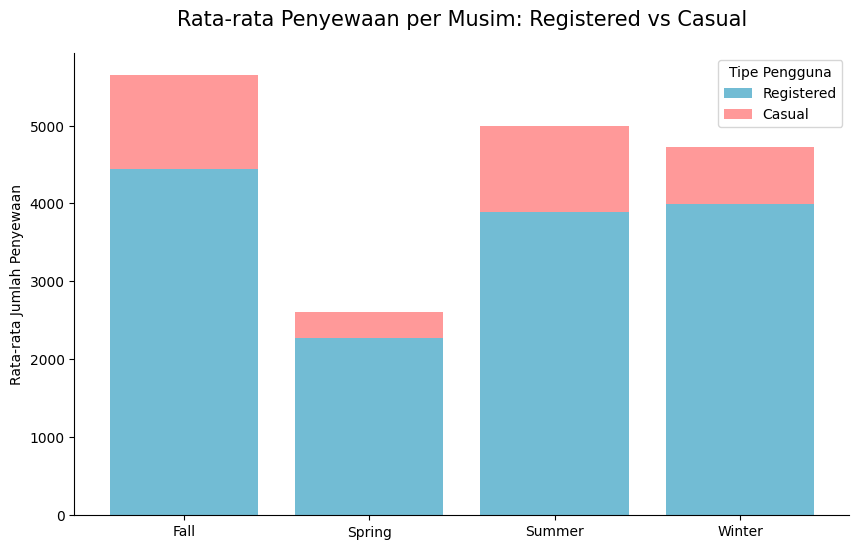

In [34]:

import matplotlib.pyplot as plt
import seaborn as sns

# Menyiapkan data: menghitung rata-rata casual dan registered per musim
season_analysis = day_df.groupby('season')[['casual', 'registered']].mean().reset_index()

# Membuat figure
plt.figure(figsize=(10, 6))

# Membuat Stacked Bar Chart
plt.bar(season_analysis['season'], season_analysis['registered'], label='Registered', color='#72BCD4')
plt.bar(season_analysis['season'], season_analysis['casual'], bottom=season_analysis['registered'], label='Casual', color='#ff9999')

# Menambahkan detail
plt.title("Rata-rata Penyewaan per Musim: Registered vs Casual", fontsize=15, pad=20)
plt.xlabel(None)
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.legend(title="Tipe Pengguna")

# Menghilangkan border atas dan kanan agar lebih clean
sns.despine()

plt.show()

### Pertanyaan 2:

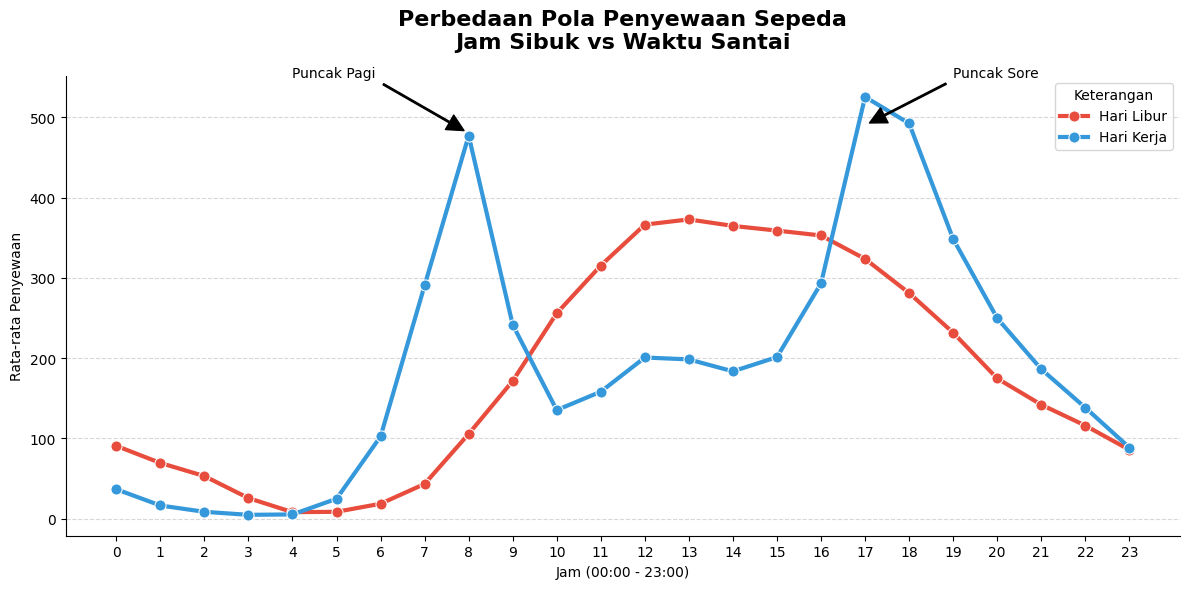

In [35]:
plt.figure(figsize=(12, 6))

# Menghitung rata-rata per jam
hourly_pattern = hour_df.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()
hourly_pattern['workingday_label'] = hourly_pattern['workingday'].map({0: 'Hari Libur', 1: 'Hari Kerja'})

# Plotting
sns.lineplot(
    data=hourly_pattern,
    x='hr',
    y='cnt',
    hue='workingday_label',
    palette=['#e74c3c', '#3498db'],
    linewidth=3,
    marker='o',
    markersize=8
)

# Menambahkan Anotasi untuk jam sibuk (Peak Hours)
plt.annotate('Puncak Pagi', xy=(8, 480), xytext=(4, 550),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))
plt.annotate('Puncak Sore', xy=(17, 490), xytext=(19, 550),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.title('Perbedaan Pola Penyewaan Sepeda\nJam Sibuk vs Waktu Santai', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Jam (00:00 - 23:00)')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Keterangan')
sns.despine()
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- xxx
- xxx

## Clustering

### Analisis Lanjutan: Manual Clustering Berdasarkan Waktu

In [36]:
def get_time_category(hour):
    if 6 <= hour <= 9:
        return 'Morning Rush'
    elif 10 <= hour <= 15:
        return 'Midday'
    elif 16 <= hour <= 19:
        return 'Evening Rush'
    else:
        return 'Quiet Hours'

hour_df['time_category'] = hour_df['hr'].apply(get_time_category)
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,time_category
0,1,2011-01-01,Spring,0,1,0,0,6,0,Misty/Cloudy,0.24,0.2879,0.81,0.0,3,13,16,Quiet Hours
1,2,2011-01-01,Spring,0,1,1,0,6,0,Misty/Cloudy,0.22,0.2727,0.80,0.0,8,32,40,Quiet Hours
2,3,2011-01-01,Spring,0,1,2,0,6,0,Clear,0.22,0.2727,0.80,0.0,5,27,32,Quiet Hours
3,4,2011-01-01,Spring,0,1,3,0,6,0,Clear,0.24,0.2879,0.75,0.0,3,10,13,Quiet Hours
4,5,2011-01-01,Spring,0,1,4,0,6,0,Clear,0.24,0.2879,0.75,0.0,0,1,1,Quiet Hours


/tmp/ipykernel_1456/2662694286.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


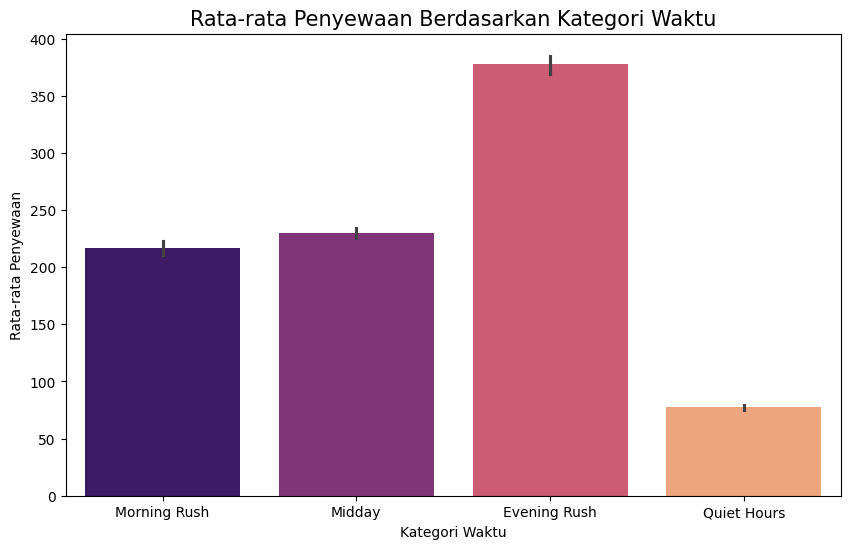

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='time_category',
    y='cnt',
    data=hour_df,
    order=['Morning Rush', 'Midday', 'Evening Rush', 'Quiet Hours'],
    palette='magma'
)
plt.title('Rata-rata Penyewaan Berdasarkan Kategori Waktu', fontsize=15)
plt.xlabel('Kategori Waktu')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

### Analisis Lanjutan: Binning Berdasarkan Volume Permintaan

In [38]:
labels = ['Low Demand', 'Medium Demand', 'High Demand', 'Very High Demand']
hour_df['demand_category'] = pd.qcut(hour_df['cnt'], q=4, labels=labels)
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,time_category,demand_category
0,1,2011-01-01,Spring,0,1,0,0,6,0,Misty/Cloudy,0.24,0.2879,0.81,0.0,3,13,16,Quiet Hours,Low Demand
1,2,2011-01-01,Spring,0,1,1,0,6,0,Misty/Cloudy,0.22,0.2727,0.80,0.0,8,32,40,Quiet Hours,Low Demand
2,3,2011-01-01,Spring,0,1,2,0,6,0,Clear,0.22,0.2727,0.80,0.0,5,27,32,Quiet Hours,Low Demand
3,4,2011-01-01,Spring,0,1,3,0,6,0,Clear,0.24,0.2879,0.75,0.0,3,10,13,Quiet Hours,Low Demand
4,5,2011-01-01,Spring,0,1,4,0,6,0,Clear,0.24,0.2879,0.75,0.0,0,1,1,Quiet Hours,Low Demand


/tmp/ipykernel_1456/236541900.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


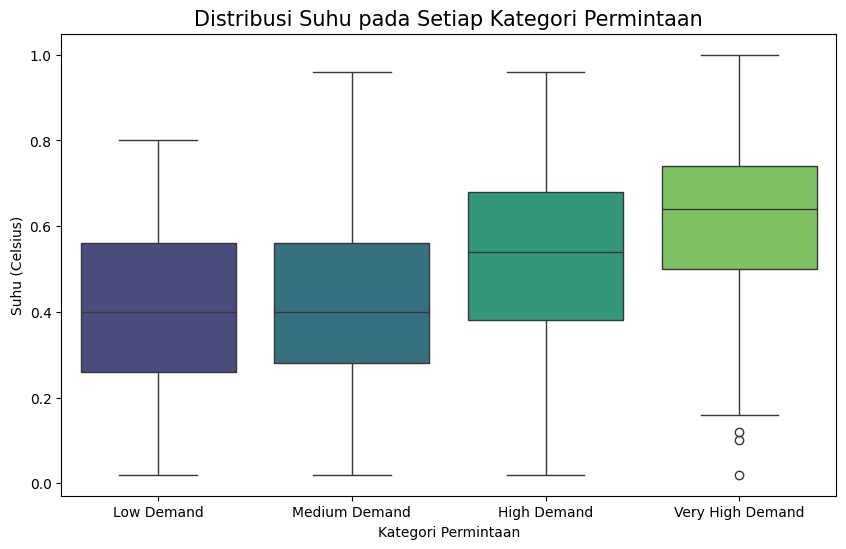

In [39]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='demand_category',
    y='temp',
    data=hour_df, # Changed from day_df to hour_df
    palette='viridis'
)
plt.title('Distribusi Suhu pada Setiap Kategori Permintaan', fontsize=15)
plt.xlabel('Kategori Permintaan')
plt.ylabel('Suhu (Celsius)')
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Musim **Fall (Musim Gugur)** adalah periode dengan rata-rata penyewaan tertinggi.
Menariknya, meskipun total penyewaan tinggi, proporsi pengguna **Registered** tetap mendominasi di semua musim,
yang menunjukkan bahwa bisnis ini memiliki basis pelanggan setia yang kuat.

- **Conclusion pertanyaan 2:** Terlihat perbedaan pola yang sangat kontras. Pada **hari kerja**, puncak penyewaan terjadi
pada jam berangkat kantor (**08:00**) dan jam pulang kantor (**17:00 - 18:00**).
Sedangkan pada **hari libur**, penyewaan meningkat secara stabil mulai siang hingga sore hari (puncaknya jam **12:00 - 15:00**).
Strategi penempatan armada harus disesuaikan dengan lonjakan di jam-jam sibuk tersebut.


**Rekomendasi Action Item:**
- **Manajemen Armada atau sepeda (Rebalancing):** Pada hari kerja, tim operasional harus memastikan ketersediaan sepeda maksimal di area pemukiman sebelum jam 8 pagi dan di area perkantoran sebelum jam 5 sore.
- **Strategi Promosi Pengguna Casual:** Mengingat pengguna casual memuncak pada hari libur di siang hari, perusahaan dapat memberikan promo khusus "Weekend Pass" atau paket rekreasi berkelompok untuk meningkatkan konversi pendapatan dari pengguna non-langganan.

- **Pemeliharaan (Maintenance):** Jadwal perawatan sepeda sebaiknya dilakukan pada jam-jam rendah permintaan (Quiet Hours), yaitu antara jam 23:00 hingga 05:00 pagi, atau pada musim Spring di mana permintaan sedang berada di titik terendah.

In [40]:
hour_df.to_csv("Main_data.csv", index=False)